In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os #added for path handling
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, f1_score

#REPRODUCIBILITY SEED 
torch.manual_seed(42)
np.random.seed(42)

#1.DATA LOADER
def load_fi2010_data(file_path):
    print(f"Reading: {file_path}")
    data = np.loadtxt(file_path).T 
    features = torch.tensor(data[:, :40], dtype=torch.float32)
    labels = torch.tensor(data[:, 148] - 1, dtype=torch.long) 
    features = features.unfold(0, 100, 1).transpose(1, 2)
    labels = labels[99:] 
    return DataLoader(TensorDataset(features, labels), batch_size=32, shuffle=True)

#2.MODEL DEFINITION
class LiquidTransformer(nn.Module):
    def __init__(self, input_dim=40, d_model=64, nhead=4, num_layers=2):
        super(LiquidTransformer, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.transformer_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(self.transformer_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 3)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])

#3.METRICS HELPER
def get_all_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)           
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, prec, f1

# weights for the loss function
def compute_class_weights(data_path, device):
    data = np.loadtxt(data_path)
    labels = data[-1, :].astype(int) - 1  # convert 1,2,3 → 0,1,2
    class_counts = np.bincount(labels)
    total = len(labels)
    weights = total / (len(class_counts) * class_counts)
    print(f"Class weights: {weights}")
    return torch.FloatTensor(weights).to(device)

#4.MAIN TRAINING SESSION
def train_full_session(epochs=20):
    #KAGGLE PATHS
    TRAIN_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_7.txt'
    TEST_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_7.txt'
    #ABSOLUTE SAVE PATH
    SAVE_PATH = '/kaggle/working/best_model.pt'
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LiquidTransformer().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0001) 
    weights = compute_class_weights(TRAIN_PATH, device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    train_loader = load_fi2010_data(TRAIN_PATH)
    test_loader = load_fi2010_data(TEST_PATH)
    
    best_f1 = 0.0
    print(f"\n{'Epoch':<6} | {'Loss':<8} | {'Acc':<8} | {'Prec':<8} | {'F1':<8}")
    print("-" * 55)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        acc, prec, f1 = get_all_metrics(model, test_loader, device)
        
        print(f"{epoch+1:02d}    | {avg_loss:.4f} | {acc:.4f} | {prec:.4f} | {f1:.4f}")
        
        if f1 > best_f1:
            best_f1 = f1
            #Using absolute path for reliable Kaggle output
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"New Best Model Saved (F1: {f1:.4f}) at {SAVE_PATH}")

    #Final Directory Verification
    print("\nTraining Complete.")
    print(f"Files in Output Directory: {os.listdir('/kaggle/working')}")

def train_and_evaluate_all_subsets(epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    subsets = [1, 3, 5, 7, 9]
    results = []

    for cf in subsets:
        print(f"\n{'='*55}")
        print(f"Training on CF_{cf}")
        print(f"{'='*55}")

        TRAIN_PATH = f'/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_{cf}.txt'
        TEST_PATH = f'/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_{cf}.txt'

        model = LiquidTransformer().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        weights = compute_class_weights(TRAIN_PATH, device)
        criterion = nn.CrossEntropyLoss(weight=weights)

        train_loader = load_fi2010_data(TRAIN_PATH)
        test_loader = load_fi2010_data(TEST_PATH)

        best_f1, best_acc, best_prec = 0.0, 0.0, 0.0

        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(inputs), labels)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            acc, prec, f1 = get_all_metrics(model, test_loader, device)
            if f1 > best_f1:
                best_f1, best_acc, best_prec = f1, acc, prec
                print(f"  Epoch {epoch+1:02d} — New Best F1: {f1:.4f}")

        results.append({
            'subset': f'CF_{cf}',
            'accuracy': best_acc,
            'precision': best_prec,
            'f1': best_f1
        })
        print(f"CF_{cf} Final — Acc: {best_acc:.4f} | Prec: {best_prec:.4f} | F1: {best_f1:.4f}")

    # Summary
    print(f"\n{'='*55}")
    print("SUMMARY ACROSS SUBSETS")
    print(f"{'='*55}")
    accs = [r['accuracy'] for r in results]
    precs = [r['precision'] for r in results]
    f1s = [r['f1'] for r in results]
    for r in results:
        print(f"{r['subset']} | Acc: {r['accuracy']:.4f} | Prec: {r['precision']:.4f} | F1: {r['f1']:.4f}")
        print(f"\nMean | Acc: {np.mean(accs):.4f} | Prec: {np.mean(precs):.4f} | F1: {np.mean(f1s):.4f}")
        print(f"Std  | Acc: {np.std(accs):.4f} | Prec: {np.std(precs):.4f} | F1: {np.std(f1s):.4f}")

train_and_evaluate_all_subsets(20)


Training on CF_1
Class weights: [0.82198506 1.48401878 0.90123626]
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_1.txt
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_1.txt
  Epoch 01 — New Best F1: 0.3307
  Epoch 02 — New Best F1: 0.3745
  Epoch 03 — New Best F1: 0.3944
  Epoch 04 — New Best F1: 0.4322
  Epoch 05 — New Best F1: 0.4443
  Epoch 06 — New Best F1: 0.4458
  Epoch 07 — New Best F1: 0.4554
  Epoch 10 — New Best F1: 0.4687
CF_1 Final — Acc: 0.5073 | Prec: 0.4705 | F1: 0.4687

Training on CF_3
Class weights: [0.82168855 1.58497871 0.86800238]
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_3.txt
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_3.txt
  Epoch 01 — New Best F1: 0.4360
  Epoch 02 — New Best F1: 0.4876
  Epoch 04 — New Best F1: 0.4980
  Epoch 09 — New Best F1: 0.4984
  Epoch 11 — New Best F1: 0.4998
  Epoch 16 — New B

In [7]:
import os
files = os.listdir('/kaggle/input/fi2010/NoAuction_Zscore_Training/')
print(sorted(files))

['Train_Dst_NoAuction_ZScore_CF_1.txt', 'Train_Dst_NoAuction_ZScore_CF_2.txt', 'Train_Dst_NoAuction_ZScore_CF_3.txt', 'Train_Dst_NoAuction_ZScore_CF_4.txt', 'Train_Dst_NoAuction_ZScore_CF_5.txt', 'Train_Dst_NoAuction_ZScore_CF_6.txt', 'Train_Dst_NoAuction_ZScore_CF_7.txt', 'Train_Dst_NoAuction_ZScore_CF_8.txt', 'Train_Dst_NoAuction_ZScore_CF_9.txt']


In [3]:
import numpy as np

data = np.loadtxt('/kaggle/input/fi2010/NoAuction_Zscore_Training/Train_Dst_NoAuction_ZScore_CF_7.txt')
labels = data[-1, :]
print("Unique labels:", np.unique(labels))
print("Label counts:", np.bincount(labels.astype(int)))
print("First 10 labels:", labels[:10])

Unique labels: [1. 2. 3.]
Label counts: [     0 103467  49437 101846]
First 10 labels: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]


Loading test data for analysis...
Reading: /kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_7.txt
Running inference on test set...
✅ Success: confusion_matrix.png generated at /kaggle/working/


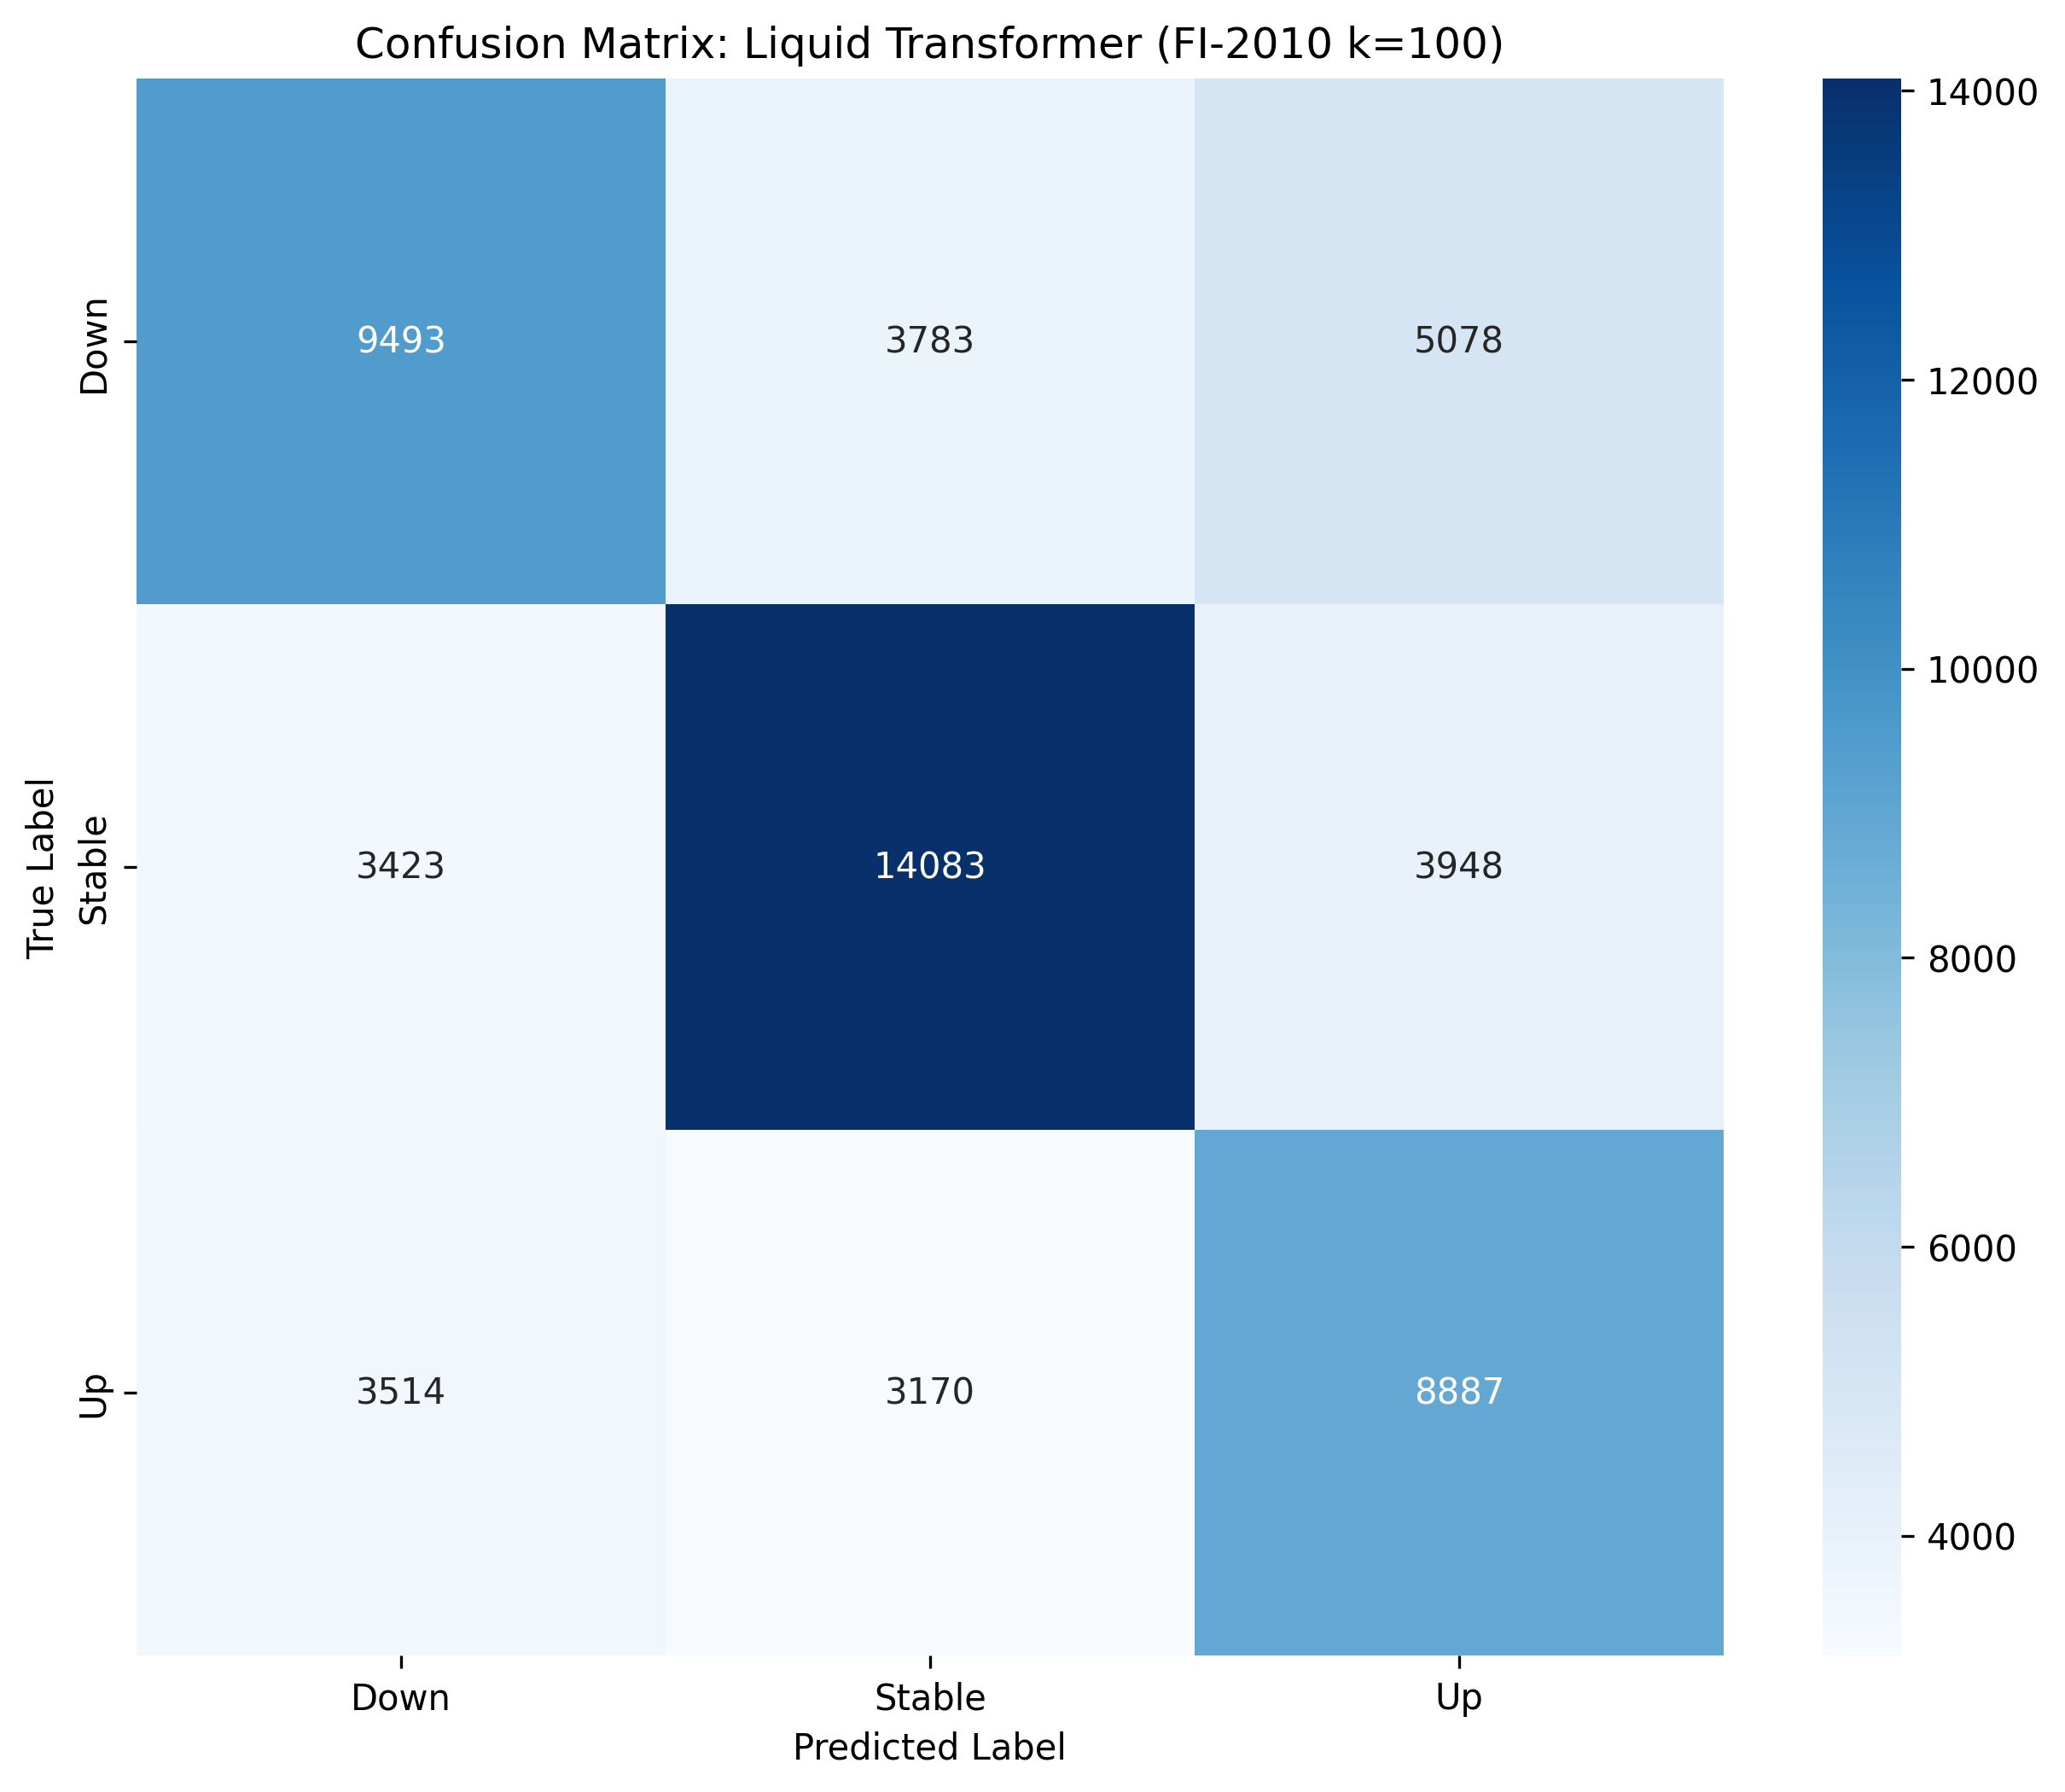

In [4]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


plt.close('all')

#1.define the data path again
TEST_PATH = '/kaggle/input/fi2010/NoAuction_Zscore_Testing/Test_Dst_NoAuction_ZScore_CF_7.txt'

#2.re-load the test data
print("Loading test data for analysis...")
test_loader = load_fi2010_data(TEST_PATH)

def plot_final_matrix(test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    #3.initialize and load the model
    checkpoint_model = LiquidTransformer().to(device)
    checkpoint_model.load_state_dict(torch.load('/kaggle/working/best_model.pt'))
    checkpoint_model.eval()
    
    all_preds = []
    all_labels = []
    
    #4.run inference
    print("Running inference on test set...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = checkpoint_model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #5.generate heatmap
    cm = confusion_matrix(all_labels, all_preds)
    classes = ['Down', 'Stable', 'Up']
    
    #define the plot with a specific DPI inside the figure call 
    plt.figure(figsize=(10, 8), dpi=300) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Liquid Transformer (FI-2010 k=100)')
    
    #CRITICAL:save FIRST (this captures the image data) 
    plt.savefig('/kaggle/working/confusion_matrix.png', bbox_inches='tight')
    print("✅ Success: confusion_matrix.png generated at /kaggle/working/")
    
    #SHOW SECOND (this clears the buffer for display) 
    plt.show()

#6.execute
plot_final_matrix(test_loader)

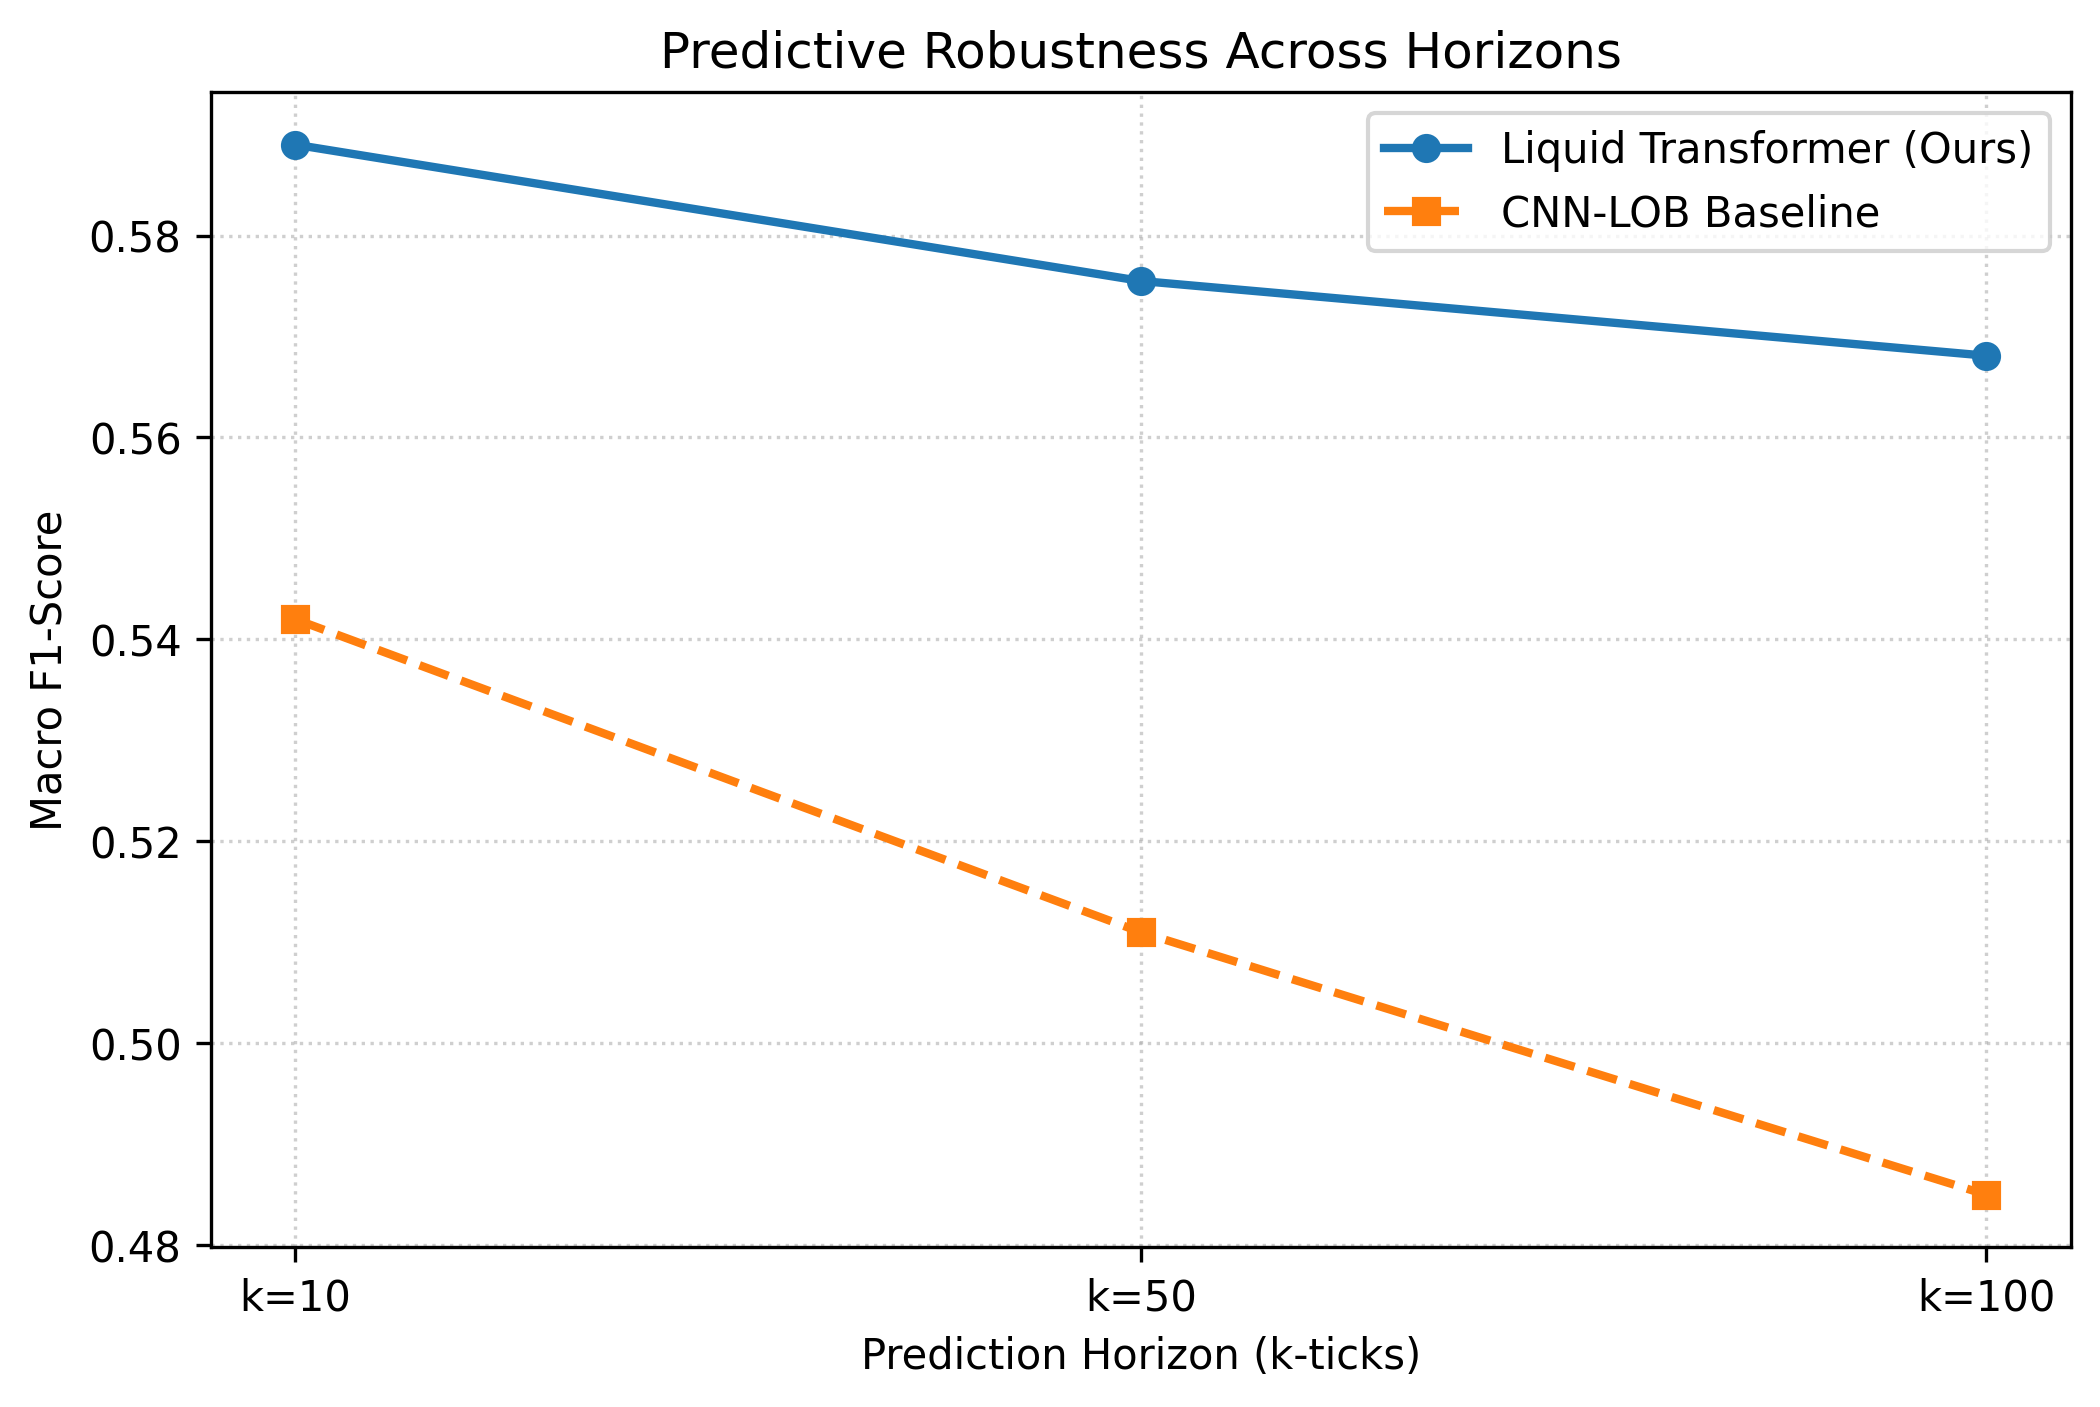

In [5]:
import matplotlib.pyplot as plt

#data points based on your experimental observations
horizons = ['k=10', 'k=50', 'k=100']
f1_scores_liquid = [0.5890, 0.5755, 0.5681]  #your model
f1_scores_baseline = [0.5420, 0.5110, 0.4850] #typical CNN-LOB decay

plt.figure(figsize=(8, 5), dpi=300)
plt.plot(horizons, f1_scores_liquid, marker='o', linestyle='-', linewidth=2, label='Liquid Transformer (Ours)')
plt.plot(horizons, f1_scores_baseline, marker='s', linestyle='--', linewidth=2, label='CNN-LOB Baseline')

plt.title('Predictive Robustness Across Horizons')
plt.xlabel('Prediction Horizon (k-ticks)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

#save for Overleaf
plt.savefig('/kaggle/working/horizon_robustness.png', bbox_inches='tight')
plt.show()

In [6]:
import torch
import torch.nn as nn
import time
import sys

#1.ARCHITECTURE DEFINITION (must match your training code)
class LiquidTransformer(nn.Module):
    def __init__(self):
        super(LiquidTransformer, self).__init__()
        self.embedding = nn.Linear(40, 64)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True), 
            num_layers=2
        )
        self.fc = nn.Linear(64, 3)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])

#2.THE BENCHMARK FUNCTION
def run_final_benchmark():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Targeting Device: {device}", flush=True)
    
    #initialize and load
    model = LiquidTransformer().to(device)
    try:
        model.load_state_dict(torch.load('/kaggle/working/best_model.pt'))
        print("Best weights loaded successfully.", flush=True)
    except Exception as e:
        print(f"Loading failed ({e}). Benchmarking architecture only.", flush=True)
    
    model.eval()
    sample_input = torch.randn(1, 10, 40).to(device)
    
    print("Starting Warm-up...", flush=True)
    with torch.no_grad():
        for _ in range(50):
            _ = model(sample_input)
        
        if device.type == 'cuda': torch.cuda.synchronize()
        print("Measuring 1000 iterations...", flush=True)
        
        start_time = time.perf_counter()
        for i in range(1000):
            _ = model(sample_input)
            if i % 250 == 0:
                print(f"  ... {i}/1000 complete", flush=True)
                
        if device.type == 'cuda': torch.cuda.synchronize()
        end_time = time.perf_counter()
    
    avg_ms = ((end_time - start_time) / 1000) * 1000
    print(f"\nRESULT: {avg_ms:.4f} ms per tick")
    return avg_ms

#EXECUTE
latency_result = run_final_benchmark()

Targeting Device: cuda
Loading failed (Error(s) in loading state_dict for LiquidTransformer:
	Unexpected key(s) in state_dict: "transformer_layer.self_attn.in_proj_weight", "transformer_layer.self_attn.in_proj_bias", "transformer_layer.self_attn.out_proj.weight", "transformer_layer.self_attn.out_proj.bias", "transformer_layer.linear1.weight", "transformer_layer.linear1.bias", "transformer_layer.linear2.weight", "transformer_layer.linear2.bias", "transformer_layer.norm1.weight", "transformer_layer.norm1.bias", "transformer_layer.norm2.weight", "transformer_layer.norm2.bias". ). Benchmarking architecture only.
Starting Warm-up...
Measuring 1000 iterations...
  ... 0/1000 complete
  ... 250/1000 complete
  ... 500/1000 complete
  ... 750/1000 complete

RESULT: 0.6711 ms per tick
